# Challenge 4: Telecom X - Parte 2

## Preparación de los Datos

### Extracción del Archivo Tratado

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("data.csv")
df.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-orfbo,0.0,f,0,1,1,9,1,0,dsl,...,1,0,1,1,0,one year,1,mailed check,65.6,593.30
1,0003-mknfe,0.0,m,0,0,0,9,1,1,dsl,...,0,0,0,0,1,month,0,mailed check,59.9,542.40
2,0004-tlhlj,1.0,m,0,0,0,4,1,0,fiber optic,...,0,1,0,0,0,month,1,electronic check,73.9,280.85
3,0011-igkff,1.0,m,1,1,0,13,1,0,fiber optic,...,1,1,0,1,1,month,1,electronic check,98.0,1237.85
4,0013-exchz,1.0,f,1,1,0,3,1,0,fiber optic,...,0,0,1,1,0,month,1,mailed check,83.9,267.40


### Eliminación de Columnas Irrelevantes

In [3]:
df = df.drop(columns=["customerID"])
df.head()

,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0.0,f,0,1,1,9,1,0,dsl,0,1,0,1,1,0,one year,1,mailed check,65.6,593.30
1,0.0,m,0,0,0,9,1,1,dsl,0,0,0,0,0,1,month,0,mailed check,59.9,542.40
2,1.0,m,0,0,0,4,1,0,fiber optic,0,0,1,0,0,0,month,1,electronic check,73.9,280.85
3,1.0,m,1,1,0,13,1,0,fiber optic,0,1,1,0,1,1,month,1,electronic check,98.0,1237.85
4,1.0,f,1,1,0,3,1,0,fiber optic,0,0,0,1,1,0,month,1,mailed check,83.9,267.40


### Encoding

In [4]:
from sklearn.preprocessing import OneHotEncoder

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Churn                      7043 non-null   float64
 1   customer_gender            7267 non-null   object 
 2   customer_SeniorCitizen     7267 non-null   int64  
 3   customer_Partner           7267 non-null   int64  
 4   customer_Dependents        7267 non-null   int64  
 5   customer_tenure            7267 non-null   int64  
 6   phone_PhoneService         7267 non-null   int64  
 7   phone_MultipleLines        7267 non-null   int64  
 8   internet_InternetService   7267 non-null   object 
 9   internet_OnlineSecurity    7267 non-null   int64  
 10  internet_OnlineBackup      7267 non-null   int64  
 11  internet_DeviceProtection  7267 non-null   int64  
 12  internet_TechSupport       7267 non-null   int64  
 13  internet_StreamingTV       7267 non-null   int64

In [6]:
categorical_cols = df.select_dtypes(include="object").columns
categorical_cols

Index(['customer_gender', 'internet_InternetService', 'account_Contract',
       'account_PaymentMethod'],
      dtype='object')

In [7]:
# Crear Encoder
encoder = OneHotEncoder(drop='first', sparse_output=False)
# ajustar Encoder
encoded_data = encoder.fit_transform(df[categorical_cols])
# Convertir df
encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=df.index
)
encoded_df.head()

,customer_gender_m,internet_InternetService_fiber optic,internet_InternetService_no,account_Contract_one year,account_Contract_two year,account_PaymentMethod_credit card (automatic),account_PaymentMethod_electronic check,account_PaymentMethod_mailed check
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [8]:
# ELiminar columnas categoricas originales
df_encoded = df.drop(columns=categorical_cols)
# Unir columnas restantes a df codificado
df_encoded = pd.concat([df_encoded, encoded_df], axis=1)
# df codificado
df_encoded.head()

,Churn,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,...,account_Charges_Monthly,account_Charges_Total,customer_gender_m,internet_InternetService_fiber optic,internet_InternetService_no,account_Contract_one year,account_Contract_two year,account_PaymentMethod_credit card (automatic),account_PaymentMethod_electronic check,account_PaymentMethod_mailed check
0,0.0,0,1,1,9,1,0,0,1,0,...,65.6,593.30,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.0,0,0,0,9,1,1,0,0,0,...,59.9,542.40,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.0,0,0,0,4,1,0,0,0,1,...,73.9,280.85,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1.0,1,1,0,13,1,0,0,1,1,...,98.0,1237.85,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.0,1,1,0,3,1,0,0,0,0,...,83.9,267.40,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [9]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 24 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Churn                                          7043 non-null   float64
 1   customer_SeniorCitizen                         7267 non-null   int64  
 2   customer_Partner                               7267 non-null   int64  
 3   customer_Dependents                            7267 non-null   int64  
 4   customer_tenure                                7267 non-null   int64  
 5   phone_PhoneService                             7267 non-null   int64  
 6   phone_MultipleLines                            7267 non-null   int64  
 7   internet_OnlineSecurity                        7267 non-null   int64  
 8   internet_OnlineBackup                          7267 non-null   int64  
 9   internet_DeviceProtection                      7267 

### Verificación de la Proporción de Cancelación (Churn)

In [10]:
df_model = df_encoded.dropna(subset=["Churn"])
X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

**Justificación:** Durante la preparación de los datos se detectaron registros con valores faltantes en la variable objetivo Churn. Dado que esta variable representa la etiqueta de clasificación, no es posible imputarla de forma confiable. Por esta razón, dichos registros fueron excluidos únicamente de la etapa de modelado.

In [11]:
# Número de clientes fugados
y.value_counts()

Churn
0.0    5174
1.0    1869
Name: count, dtype: int64

In [12]:
# Porcentaje de clientes fugados
y.value_counts(normalize=True)

Churn
0.0    0.73463
1.0    0.26537
Name: proportion, dtype: float64

#### Gráfica Fuga

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

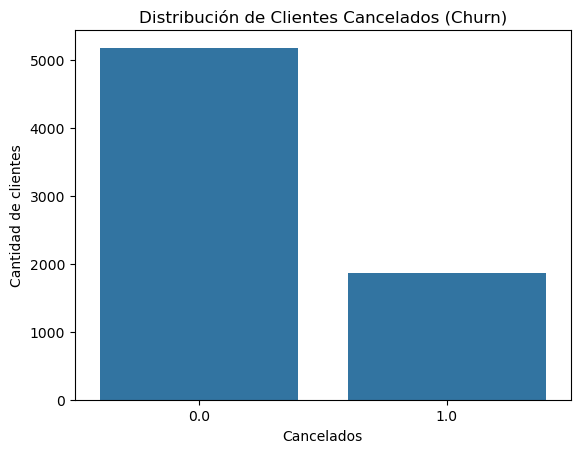

In [14]:
sns.countplot(x=y)
plt.title("Distribución de Clientes Cancelados (Churn)")
plt.xlabel("Cancelados")
plt.ylabel("Cantidad de clientes")
plt.show()

**Interpretación:** La variable objetivo presenta un desbalance moderado entre clientes que cancelan el servicio y aquellos que permanecen activos. Aproximadamente el 27 % de los clientes cancelan el servicio, mientras que el 73 % continúa utilizando la plataforma.

**Justificación de la estrategia:** Debido a que el desbalance no es extremo, se decidió no aplicar técnicas de sobremuestreo o submuestreo. En su lugar, se utilizará el parámetro *`class_weight='balanced'`* en los modelos de machine learning, lo que permite ajustar el peso de cada clase durante el entrenamiento sin alterar la distribución original de los datos.

## Correlación y Selección de Variables

### Análisis de Correlación

In [15]:
correlation_matrix = df_model.corr()

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

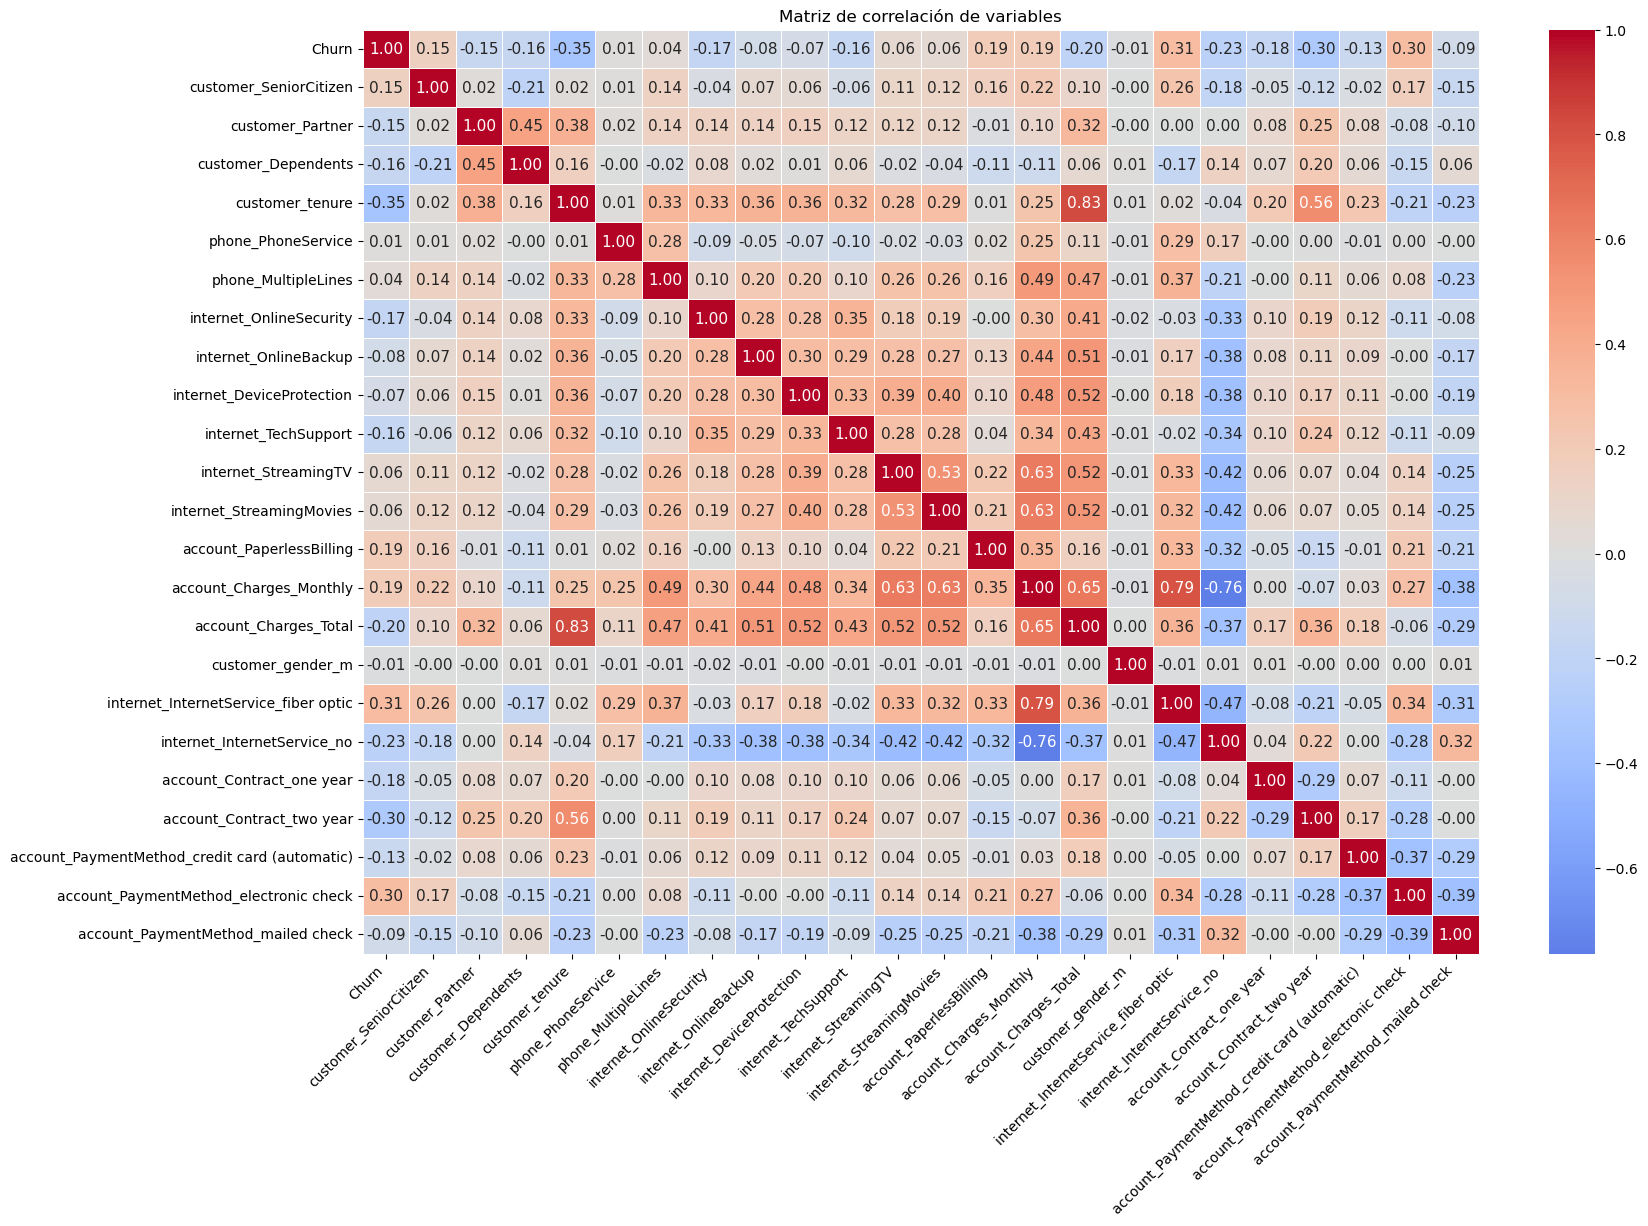

In [17]:
plt.figure(figsize=(18, 12))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size": 11}
)
plt.title("Matriz de correlación de variables")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

**Interpretación:** En la correlación con la cancelación, el análisis muestra que variables como `account_PaperlessBilling` y `account_Charges_Monthly` presentan una relación relevante con la cancelación del servicio. En particular, `internet_InternetService_fiber optic`, `account_PaymentMethod_electronic check` y `account_Charges_Monthly` presentan una mayor probabilidad de cancelar el servicio.
En la correlación indica posible multicolinealidad entre las variables `customer_tenure ↔ account_Charges_Total`, `account_Charges_Monthly ↔ InternetService_fiber optic`, `account_Charges_Monthly ↔ StreamingTV` y `account_Charges_Monthly ↔ StreamingMovies`. 

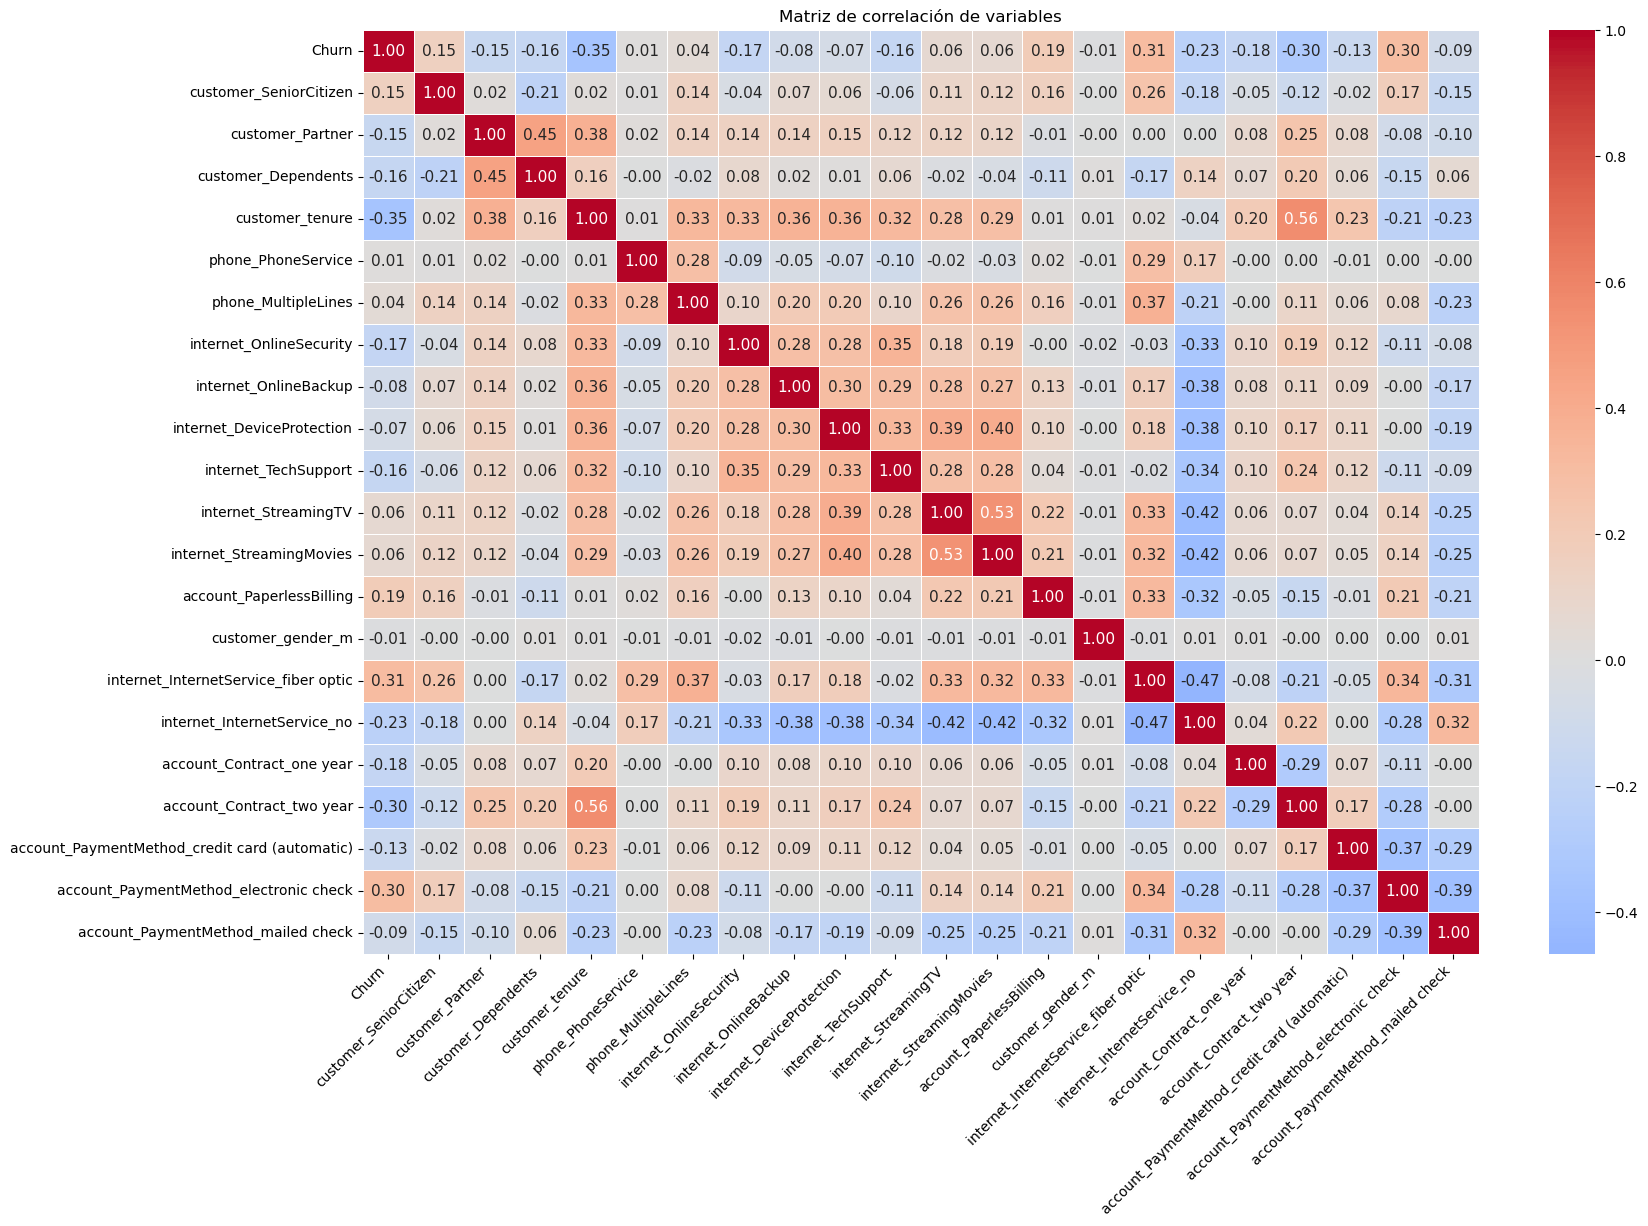

In [18]:
df_model_drop_features = df_model.drop(["account_Charges_Total", "account_Charges_Monthly"], axis=1)
correlation_matrix_drop = df_model_drop_features.corr()
plt.figure(figsize=(18, 12))
sns.heatmap(
    correlation_matrix_drop,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size": 11}
)
plt.title("Matriz de correlación de variables")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

**Justificación:** Se realizó un análisis de correlación entre las variables del conjunto de datos con el objetivo de identificar relaciones lineales y posibles problemas de multicolinealidad. Las variables *`account_Charges_Total`* y *`account_Charges_Monthly`* fueron eliminadas debido a su alta dependencia con el tiempo de permanencia del *`customer_tenure`*. Esto permite reducir redundancia en la información y mejorar la estabilidad de los modelos de regresión.

### Análisis Dirigido

**Tiempo de contrato × Cancelación**

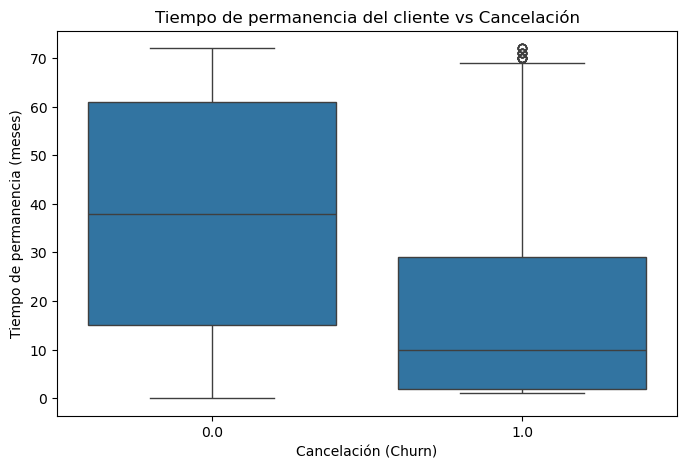

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="Churn",
    y="customer_tenure",
    data=df_model
)
plt.title("Tiempo de permanencia del cliente vs Cancelación")
plt.xlabel("Cancelación (Churn)")
plt.ylabel("Tiempo de permanencia (meses)")
plt.show()

**Interpretación:** El análisis muestra que los clientes con menor tiempo de permanencia presentan una mayor tasa de cancelación. Esto sugiere que los primeros meses del servicio son un período crítico para la retención de clientes.

**Gasto total × Cancelación**

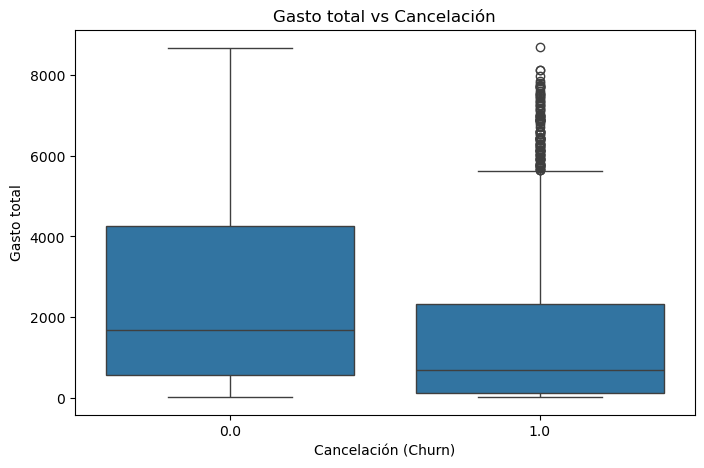

In [20]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="Churn",
    y="account_Charges_Total",
    data=df_model
)
plt.title("Gasto total vs Cancelación")
plt.xlabel("Cancelación (Churn)")
plt.ylabel("Gasto total")
plt.show()

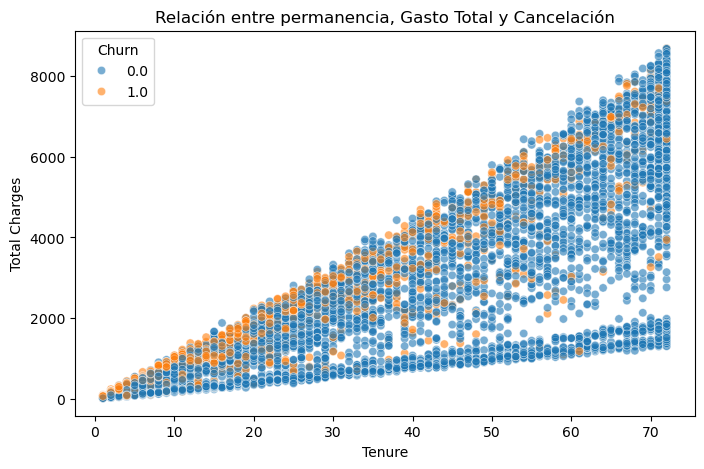

In [21]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x="customer_tenure",
    y="account_Charges_Total",
    hue="Churn",
    data=df_model,
    alpha=0.6
)
plt.title("Relación entre permanencia, Gasto Total y Cancelación")
plt.xlabel("Tenure")
plt.ylabel("Total Charges")
plt.show()

**Interpretación:** Los clientes con mayor gasto total tienden a presentar menores niveles de cancelación. Esto puede explicarse porque estos clientes suelen tener mayor antigüedad o utilizan más servicios de la compañía.

## Modelado Predictivo

### Separación de Datos

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

**Verificar tamaños**

In [25]:
print(f"Datos de entrenamiento: {X_train.shape}")
print(f"Datos de prueba: {X_test.shape}")

Datos de entrenamiento: (4930, 23)
Datos de prueba: (2113, 23)


**Verificar balance de churn**

In [26]:
print("Distribución en entrenamiento")
print(y_train.value_counts(normalize=True))

print("\nDistribución en prueba")
print(y_test.value_counts(normalize=True))

Distribución en entrenamiento
Churn
0.0    0.734686
1.0    0.265314
Name: proportion, dtype: float64

Distribución en prueba
Churn
0.0    0.734501
1.0    0.265499
Name: proportion, dtype: float64


### Creación de Modelos

#### RandomForest

In [48]:
from sklearn.ensemble import RandomForestClassifier

**Crear modelo**

In [49]:
modelo_rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

**Entrenar modelo**

In [50]:
modelo_rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


**Realizar predicciones**

In [55]:
y_pred_rf = modelo_rf.predict(X_test)

**Evaluar modelo**

In [58]:
from sklearn.metrics import classification_report

In [59]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

         0.0       0.82      0.90      0.86      1552
         1.0       0.63      0.47      0.54       561

    accuracy                           0.79      2113
   macro avg       0.73      0.68      0.70      2113
weighted avg       0.77      0.79      0.77      2113



**Interpretación:** El modelo Random Forest alcanzó una precisión global cercana al 79%. Sin embargo, al analizar las métricas por clase se observa que el modelo identifica con mayor precisión a los clientes que permanecen en el servicio que a aquellos que cancelan. El recall para la clase churn es de 0.47, lo que indica que aproximadamente el 47% de los clientes que cancelan son correctamente detectados por el modelo.

**Matriz de confusión**

In [60]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

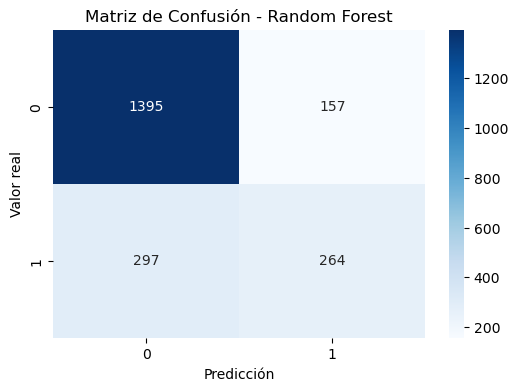

In [61]:
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

**Interpretación:**

La matriz de confusión permite analizar en detalle el desempeño del modelo al clasificar clientes que permanecen en el servicio y aquellos que cancelan (churn).
En el conjunto de prueba se evaluaron 2113 clientes, distribuidos de la siguiente manera:

  - 1552 clientes que no cancelaron el servicio.

  - 561 clientes que sí cancelaron.

El modelo produjo los siguientes resultados:

  - ***Verdaderos negativos (TN)***: El modelo clasificó correctamente 1395 clientes que no cancelaron el servicio. Estos corresponden a clientes cuyo valor real era 0 (no churn) y que el modelo también predijo como 0. Esto indica que el modelo tiene una buena capacidad para identificar clientes que permanecerán en la compañía.
  
  - ***Falsos positivos (FP)***: El modelo clasificó incorrectamente 157 clientes como churn cuando en realidad no cancelaron el servicio. Estos corresponden a clientes cuyo valor real era 0, pero el modelo predijo 1. Desde el punto de vista del negocio, esto significa que se podrían aplicar acciones de retención innecesarias a algunos clientes que en realidad no tenían intención de cancelar.

  - ***Falsos negativos (FN)***: El modelo no detectó 297 clientes que efectivamente cancelaron el servicio. Estos clientes tenían valor real 1 (churn), pero el modelo predijo 0. Este es el error más relevante en problemas de churn, ya que representa clientes que abandonan la compañía sin ser identificados previamente como casos de riesgo.

  - ***Verdaderos positivos (TP)***: El modelo identificó correctamente 264 clientes que cancelaron el servicio. Estos corresponden a clientes cuyo valor real era 1, y que el modelo predijo correctamente como 1. Estos casos representan clientes en riesgo que podrían ser objetivo de estrategias de retención.

***Conclusión***: En general, el modelo muestra un buen desempeño para identificar clientes que permanecen en el servicio, con un alto número de verdaderos negativos. Sin embargo, su capacidad para detectar todos los casos de cancelación es más limitada. De los 561 clientes que cancelaron, el modelo identificó correctamente 264, lo que equivale aproximadamente al 47% de los casos de churn. Esto sugiere que, aunque el modelo tiene un desempeño general adecuado, existe margen de mejora en la detección de clientes con riesgo de cancelación, lo cual podría lograrse ajustando el modelo o evaluando diferentes algoritmos.

**Importancia de variables**

In [62]:
import pandas as pd

In [63]:
importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)
importancias.head(10)

account_Charges_Total                     0.176223
customer_tenure                           0.170915
account_Charges_Monthly                   0.159152
account_Contract_two year                 0.062866
internet_InternetService_fiber optic      0.051997
account_PaymentMethod_electronic check    0.039099
account_Contract_one year                 0.034130
account_PaperlessBilling                  0.028089
customer_gender_m                         0.026431
customer_Partner                          0.022539
dtype: float64

**Visualizar importancia de las variables**

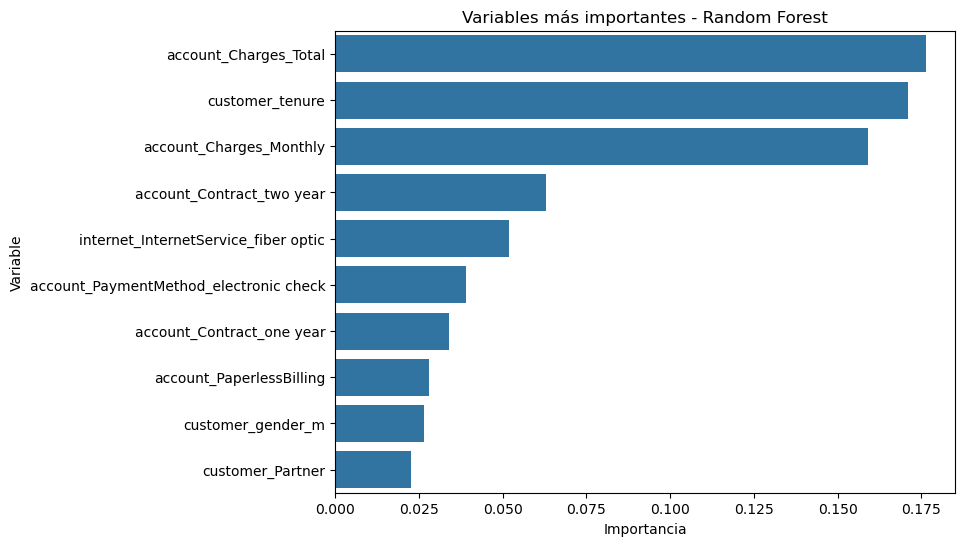

In [64]:
plt.figure(figsize=(8, 6))
sns.barplot(
    x=importancias.head(10),
    y=importancias.head(10).index
)
plt.title("Variables más importantes - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

**Interpretación:** En general, las variables más importantes identificadas por el modelo están relacionadas con account_Charges_Total, customer_tenure, account_Charges_Monthly y account_Contract_two year. Estos factores reflejan tanto el nivel de compromiso del cliente con la compañía como las condiciones económicas del servicio, lo que los convierte en indicadores relevantes para anticipar posibles cancelaciones. Este análisis permite comprender mejor los factores que influyen en el churn y puede servir como base para diseñar estrategias de retención enfocadas en clientes con mayor riesgo de cancelación.

**Curva ROC**

In [65]:
from sklearn.metrics import roc_curve, roc_auc_score

**Obtener probabilidades del modelo**

In [67]:
y_prob_rf = modelo_rf.predict_proba(X_test)[:, 1]

**Calcular la curva ROC**

In [68]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

**Calcular el AUC:** Mide la capacidad del modelo para separar ambas clases.

In [69]:
auc_rf = roc_auc_score(y_test, y_prob_rf)
print("AUC:", auc_rf)

AUC: 0.8242828527849752


**Gráfica curva ROC**

In [70]:
import matplotlib.pyplot as plt

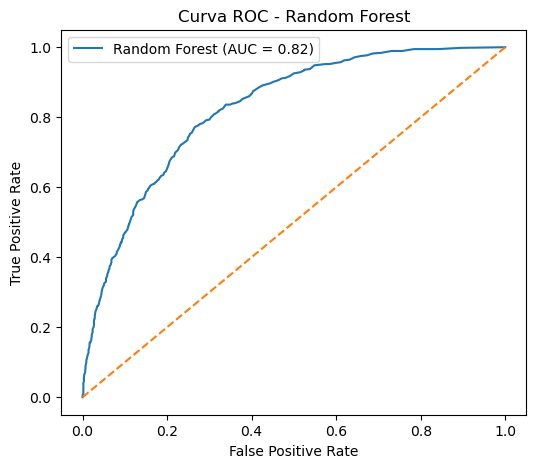

In [71]:
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc_rf:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Random Forest")
plt.legend()
plt.show()

**Interpretación:** La curva ROC muestra la capacidad del modelo para distinguir entre clientes que cancelan el servicio y aquellos que permanecen. El área bajo la curva (AUC) obtenida fue de 0.82, lo que indica un buen desempeño del modelo en la discriminación entre ambas clases. Este resultado sugiere que el modelo Random Forest posee una capacidad adecuada para identificar clientes con riesgo de cancelación.

#### Regresión Logística

**Separación de datos**

In [72]:
df_model_drop_features = df_model.drop(["account_Charges_Total", "account_Charges_Monthly"], axis=1)
X_rl = df_model_drop_features.drop("Churn", axis=1)
y_rl = df_model_drop_features["Churn"]

X_train_rl, X_test_rl, y_train_rl, y_test_rl = train_test_split(
    X_rl,
    y_rl,
    test_size=0.3,
    random_state=42,
    stratify=y_rl
)

**Verificar tamaños**

In [73]:
print(f"Datos de entrenamiento: {X_train_rl.shape}")
print(f"Datos de prueba: {X_test_rl.shape}")

Datos de entrenamiento: (4930, 21)
Datos de prueba: (2113, 21)


**Verificar balance de churn**

In [74]:
print("Distribución en entrenamiento")
print(y_train_rl.value_counts(normalize=True))

print("\nDistribución en prueba")
print(y_test_rl.value_counts(normalize=True))

Distribución en entrenamiento
Churn
0.0    0.734686
1.0    0.265314
Name: proportion, dtype: float64

Distribución en prueba
Churn
0.0    0.734501
1.0    0.265499
Name: proportion, dtype: float64


**Normalización o Estandarización**

In [75]:
from sklearn.preprocessing import StandardScaler

In [76]:
# Instanciar el escalador
scaler = StandardScaler()

In [77]:
# Ajustar el escalador
X_train_rl_scaled = scaler.fit_transform(X_train_rl)

In [78]:
# Solo Transformar los datos de prueba
X_test_rl_scaled = scaler.transform(X_test_rl)

**Justificación:** Para el modelo de regresión logística se aplicó estandarización mediante *`StandardScaler`*. Este procedimiento transforma las variables para que tengan media cero y desviación estándar uno, lo cual es importante para modelos sensibles a la escala de los datos. Los modelos basados en árboles, como Random Forest, no requieren este paso.

**Entrenar modelo**

In [79]:
from sklearn.linear_model import LogisticRegression

In [80]:
modelo_rl = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)
modelo_rl.fit(X_train_rl_scaled, y_train_rl)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


**Realizar predicciones**

In [81]:
y_pred_rl = modelo_rl.predict(X_test_rl_scaled)

**probabilidades**

In [82]:
y_prob_rl = modelo_rl.predict_proba(X_test_rl_scaled)[:,1]

**evaluar modelo**

In [83]:
from sklearn.metrics import classification_report

In [84]:
print(classification_report(y_test_rl, y_pred_rl))

              precision    recall  f1-score   support

         0.0       0.90      0.72      0.80      1552
         1.0       0.50      0.79      0.61       561

    accuracy                           0.74      2113
   macro avg       0.70      0.75      0.71      2113
weighted avg       0.80      0.74      0.75      2113



**Interpretación:** El modelo de regresión logística presenta un desempeño razonable, con una accuracy del 74 %. Además, muestra una alta capacidad para detectar clientes que cancelarán el servicio (recall de 0.79).
Sin embargo, la precision para churn es relativamente baja (0.50), lo que significa que el modelo tiende a clasificar como cancelación a algunos clientes que en realidad no cancelarán.
A pesar de esta limitación, el modelo puede ser útil en estrategias de retención, ya que permite identificar la mayoría de los clientes con riesgo de cancelación, lo que facilita la aplicación de acciones preventivas por parte de la empresa.

**Matriz de confusión**

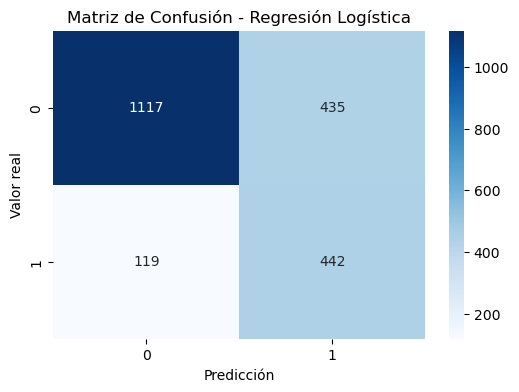

In [85]:
cm_rl = confusion_matrix(y_test_rl, y_pred_rl)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rl, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

**Interpretación:** 

El modelo produjo los siguientes resultados:

  - ***Verdaderos negativos (TN):*** El modelo identificó correctamente 1117 clientes que no cancelaron el servicio. Esto indica que el modelo tiene una buena capacidad para reconocer clientes que permanecerán.
  
  - ***Falsos positivos (FT):*** En 435 casos, el modelo predijo que los clientes cancelarían el servicio, pero en realidad no lo hicieron. Este tipo de error puede generar acciones de retención innecesarias, como ofertas o descuentos dirigidos a clientes que en realidad no planeaban cancelar.

  - ***Falsos negativos (FN):*** El modelo no logró detectar 119 clientes que efectivamente cancelaron el servicio, clasificándolos como clientes que permanecerían. Este es uno de los errores más importantes en problemas de churn, ya que implica no anticipar la pérdida de clientes.

  - ***Verdaderos positivos (TT):*** El modelo logró identificar correctamente 442 clientes que cancelaron el servicio. Esto demuestra que el modelo tiene una buena capacidad para detectar churn, lo que puede ser útil para implementar estrategias de retención antes de que los clientes abandonen la compañía.

***Conclusión:*** En general, el modelo de regresión logística logra identificar correctamente una gran cantidad de clientes que cancelan el servicio (442 casos detectados), aunque también genera un número considerable de falsos positivos (435 casos).
A pesar de esto, el modelo puede ser útil para estrategias de retención, ya que prioriza la detección de clientes con riesgo de cancelación, lo que permite a la empresa intervenir antes de que ocurra la pérdida del cliente.

**Curva ROC para Regresión Logística**

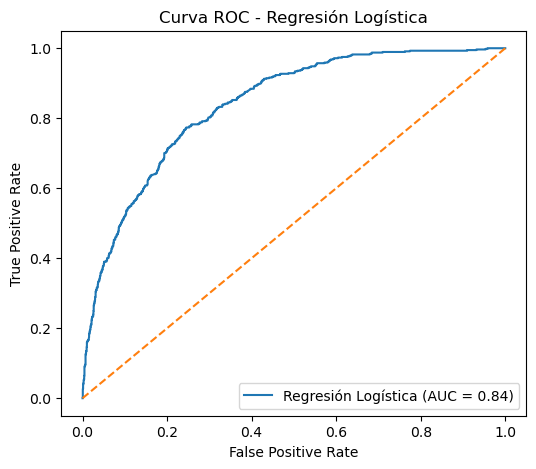

In [86]:
fpr_rl, tpr_rl, _ = roc_curve(y_test_rl, y_prob_rl)
auc_rl = roc_auc_score(y_test_rl, y_prob_rl)
plt.figure(figsize=(6, 5))
plt.plot(fpr_rl, tpr_rl, label=f"Regresión Logística (AUC = {auc_rl:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Regresión Logística")
plt.legend()
plt.show()

**Interpretación:** El modelo de regresión logística presenta un buen desempeño predictivo, con un AUC de 0.84, lo que indica una capacidad sólida para distinguir entre clientes que cancelan y clientes que permanecen en el servicio.
Este resultado sugiere que el modelo puede ser utilizado como herramienta para identificar clientes con riesgo de cancelación y aplicar estrategias preventivas de retención.

## Comparación de modelos: Random Forest vs Regresión Logística

### 1. ¿Cuál modelo tuvo el mejor desempeño?

Al comparar ambos modelos, se observan diferencias importantes en sus métricas de desempeño de ***Random Forest:***
  - Accuracy: 0.79
  - F1-score churn (clase 1): 0.54
  - Recall churn: 0.47
  - AUC-ROC: 0.82

Este modelo clasifica muy bien a los clientes que no abandonan el servicio (clase 0), con un recall de 0.90. Sin embargo, tiene más dificultad para detectar correctamente a los clientes que sí abandonan (churn).

La matriz de confusión muestra:

  - 1395 verdaderos negativos
  - 157 falsos positivos
  - 297 falsos negativos
  - 264 verdaderos positivos

Esto indica que el modelo pierde bastantes clientes que realmente abandonan (297).

***Regresión Logística:***
  - Accuracy: 0.74
  - F1-score churn: 0.61
  - Recall churn: 0.79
  - AUC-ROC: 0.84

La regresión logística tiene menor accuracy, pero detecta mejor a los clientes que abandonan el servicio.

En su matriz de confusión:

  - 1117 verdaderos negativos
  - 435 falsos positivos
  - 119 falsos negativos
  - 442 verdaderos positivos

Este modelo identifica muchos más casos de churn que Random Forest.

#### Comparación general

Métrica	Random Forest	Regresión Logística
Accuracy	0.79	0.74
Recall churn	0.47	0.79
F1 churn	0.54	0.61
AUC-ROC	0.82	0.84

#### Conclusión

  - Si el objetivo es maximizar la precisión global, el mejor modelo es Random Forest.
  - Si el objetivo es detectar clientes que abandonarán el servicio, el mejor modelo es Regresión Logística, ya que identifica muchos más casos de churn.

En problemas de churn, normalmente es más importante detectar clientes en riesgo, por lo que la Regresión Logística resulta más útil en este caso.

### 2. Overfitting o Underfitting

***Random Forest***

No hay señales claras de overfitting, ya que el desempeño en test sigue siendo razonablemente alto. Sin embargo, se observa que el modelo prioriza mucho la clase mayoritaria (no churn). Esto puede deberse a:
  - Desbalance de clases
  - Falta de ajuste de hiperparámetros

Posibles mejoras:
  - Ajustar max_depth
  - Ajustar min_samples_leaf
  - Usar class_weight='balanced'
  - Aplicar técnicas de balanceo como SMOTE

***Regresión Logística***

La regresión logística puede mostrar cierto underfitting, ya que es un modelo lineal y puede no capturar relaciones complejas entre las variables.
Sin embargo, en este caso logra mejor capacidad de detección de churn, lo que indica que el patrón en los datos podría ser relativamente lineal.

### Conclusión final

En este análisis:

Random Forest obtuvo mayor accuracy (0.79).

Regresión Logística obtuvo mejor detección de churn, con:

  - mayor recall (0.79)
  - mayor F1-score (0.61)
  - mayor AUC-ROC (0.84).

Por esta razón, la Regresión Logística resulta el modelo más adecuado para este problema, ya que permite identificar de forma más efectiva a los clientes con riesgo de abandono.